In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Task 1: MCP Neuron for AND and OR
Manually building a simple neuron called MCP neuron that


1.   takes binary input
2.   adds them
3.   compare the sum to threshold
4. output either 1 or 0



In [15]:
def MCP_Neurons_AND(X1, X2, T):
    """
    Implements AND operation using an MCP neuron.
    """
    assert len(X1) == len(X2)
    state_neuron = []

    for i in range(len(X1)):
        s = X1[i] + X2[i]
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 2

result_and = MCP_Neurons_AND(X1, X2, T)
print("AND result:", result_and)

AND result: [0, 0, 0, 1]


In [16]:
def MCP_Neurons_OR(X1, X2, T):
    """
    Implements OR operation using an MCP neuron.
    """
    assert len(X1) == len(X2)
    state_neuron = []

    for i in range(len(X1)):
        s = X1[i] + X2[i]
        if s >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)

    return state_neuron


X1 = [0, 0, 1, 1]
X2 = [0, 1, 0, 1]
T = 1

result_or = MCP_Neurons_OR(X1, X2, T)
print("OR result:", result_or)

OR result: [0, 1, 1, 1]


### Question 1: Limitations of MCP neurons
1. MCP neurons do not learn from data.  
2. Their threshold is fixed manually.  
3. A single MCP neuron can only solve simple linearly separable problems.  
4. It cannot handle complex real-world patterns well.  
5. Output is only binary, so it cannot represent gradual values.  
6. It is too simple for tasks like image recognition directly.  
7. It is only a rough abstraction of a biological neuron.

# Task 2: Perceptron for 0 Vs 1 Classification
Using perceptron is better than MCP because it uses weights, bias and it can learn from mistakes. In this task we digitally classify handwritten digits.

Each Image has 28 X 28 pixels totaling to 784 features.

In [17]:
#Loading the dataset
df_0_1 = pd.read_csv("/content/drive/MyDrive/AIML/data/mnist_0_and_1.csv")

X = df_0_1.drop(columns=["label"]).values
y = df_0_1["label"].values

print("Feature matrix shape:", X.shape)
print("Label vector shape:", y.shape)

Feature matrix shape: (12665, 784)
Label vector shape: (12665,)


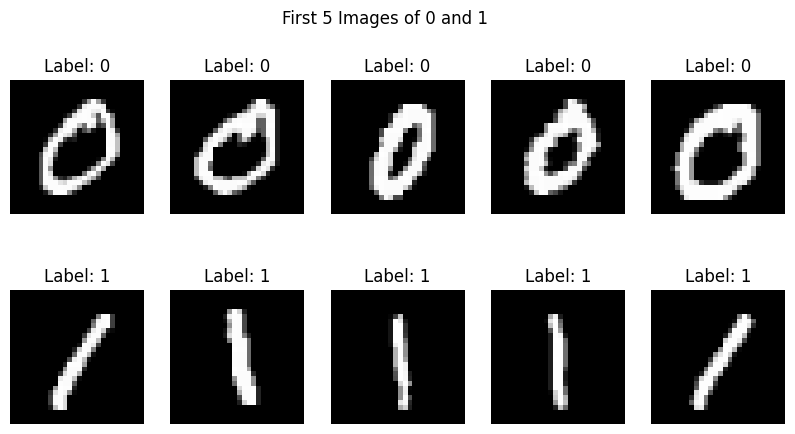

In [18]:
#Visualizing some images
images_0 = X[y == 0]
images_1 = X[y == 1]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_0) < 5 or len(images_1) < 5:
    print("Error: Not enough images to display.")
else:
    for i in range(5):
        axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 0")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 1")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 0 and 1")
    plt.show()

# Initializing weights and bias
creating 784 weights, one for each pixel, 1 bias value, learning rate and number of epoch

In [19]:
weights = np.zeros(X.shape[1])
bias = 0
learning_rate = 0.1
epochs = 100

**Question 3:** What does the weights array represent in this context?
The weights array stores one weight for each input pixel.  
Each weight tells the model how important that pixel is for deciding whether the image is 0 or 1.

Question 4: Why are we initializing the weights to zero? What effect could this have on the training process?
We initialize weights to zero to start from a simple neutral point.  
The model begins with no preference and learns by updating the weights during training.


# Decision Function

This function makes predictions by doing two things
1. computing the weighted sum
2. applies the step function:
if value ≥ 0 = predict 1
   - otherwise = predict 0

In [20]:
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

## Step 2.5: Train the perceptron

This is the actual learning part.

For each training example:
1. compute output
2. make a prediction
3. compare prediction with true label
4. if wrong:
   - update weights
   - update bias

This is how the perceptron learns from mistakes.

In [21]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    for epoch in range(epochs):
        correct_predictions = 0

        for i in range(len(X)):
            output = np.dot(X[i], weights) + bias
            y_pred = 1 if output >= 0 else 0

            if y_pred == y[i]:
                correct_predictions += 1
            else:
                error = y[i] - y_pred
                weights = weights + learning_rate * error * X[i]
                bias = bias + learning_rate * error

        accuracy = correct_predictions / len(X)

    return weights, bias, accuracy


**Question 5: What is the purpose of output = np.dot(X[i], weights) + bias?**  
It computes the weighted sum of the input features plus the bias.  
This value is used to decide the predicted class.

**Question 6: What happens when the prediction is wrong? How are the weights and bias updated?**  
When prediction is wrong:
- error = y[i] - y_pred
- weights update by  
  weights = weights + learning_rate * error * X[i]
- bias updates by  
  bias = bias + learning_rate * error

This pushes the model toward more correct predictions.

**Question 7: Why is the final accuracy important, and what do you expect it to be?**  
Final accuracy tells us how well the model learned.  
For 0 vs 1, we expect a very high accuracy because the digits are easier to separate.

# Train and Evaluate on 0 vs 1
 now using the training function to learn the weights and bias, then compute the final predictions and accuracy.

In [22]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100)
print("Final Training Accuracy:", accuracy)

predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)

final_accuracy = np.mean(y_pred == y)
print(f"Final Accuracy: {final_accuracy:.4f}")

Final Training Accuracy: 1.0
Final Accuracy: 1.0000


Final accuracy for 0 vs 1 is 1.000

That means the perceptron classifies this dataset perfectly.

# Show misclassified images for 0 vs 1

Finding all image indices where the predicted label is not equal to true label. then we display those images.

In [23]:
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx[:10]):
        ax.imshow(X[idx].reshape(28, 28), cmap="gray")
        ax.set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        ax.axis("off")
    plt.suptitle("Misclassified Images (0 vs 1)")
    plt.show()
else:
    print("All images were correctly classified!")

All images were correctly classified!


### Answers
**Question 8: What does misclassified_idx store, and how is it used in this code?**  
It stores the indices of incorrectly classified images.  
Those indices are then used to display the wrong predictions.

**Question 9: How do you interpret the result if the output is All images were correctly classified!?**  
It means there were no mistakes on the evaluated dataset, so the model achieved 100% accuracy.

# Task 3: Perceptron for 3 vs 5
this task repeats the same thing but now for digits 3 and 5

In [24]:
#loading the dataset
df_3_5 = pd.read_csv("/content/drive/MyDrive/AIML/data/mnist_3_and_5.csv")

X_35 = df_3_5.drop(columns=["label"]).values
y_35 = df_3_5["label"].values

print("Feature matrix shape:", X_35.shape)
print("Label vector shape:", y_35.shape)

Feature matrix shape: (2741, 784)
Label vector shape: (2741,)


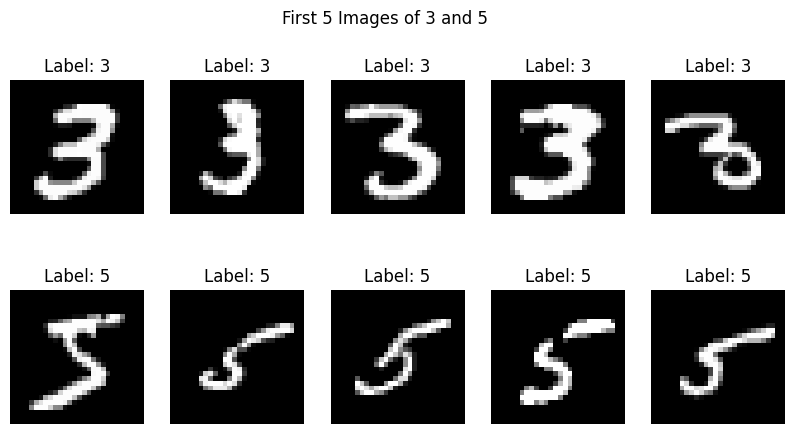

In [25]:
#visualizing some 3s and 5s
images_3 = X_35[y_35 == 3]
images_5 = X_35[y_35 == 5]

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

if len(images_3) < 5 or len(images_5) < 5:
    print("Error: Not enough images to display.")
else:
    for i in range(5):
        axes[0, i].imshow(images_3[i].reshape(28, 28), cmap="gray")
        axes[0, i].set_title("Label: 3")
        axes[0, i].axis("off")

        axes[1, i].imshow(images_5[i].reshape(28, 28), cmap="gray")
        axes[1, i].set_title("Label: 5")
        axes[1, i].axis("off")

    plt.suptitle("First 5 Images of 3 and 5")
    plt.show()

##Convert labels to binary

Perceptron expects binary classes like 0 and 1.

So we convert:
- digit 3 to 0
- digit 5 to 1

In [26]:
y_35_binary = np.where(y_35 == 3, 0, 1)

##Train the perceptron on 3 vs 5

We initialize weights and bias again, then reuse the same training function.

In [27]:
weights_35 = np.zeros(X_35.shape[1])
bias_35 = 0
learning_rate = 0.1
epochs = 100

weights_35, bias_35, accuracy_35 = train_perceptron(
    X_35, y_35_binary, weights_35, bias_35, learning_rate=learning_rate, epochs=epochs
)

print("Final Training Accuracy for 3 vs 5:", accuracy_35)

Final Training Accuracy for 3 vs 5: 0.9857716161984678


## Evaluate and visualize misclassified images

We compute the final predictions, calculate accuracy, and display the incorrectly classified images.

Final Accuracy for 3 vs 5: 0.9869


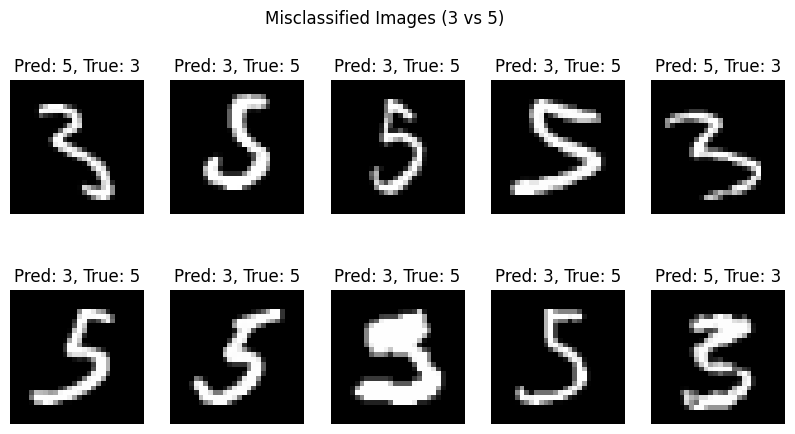

In [28]:
predictions_35 = np.dot(X_35, weights_35) + bias_35
y_pred_35 = np.where(predictions_35 >= 0, 1, 0)

final_accuracy_35 = np.mean(y_pred_35 == y_35_binary)
print(f"Final Accuracy for 3 vs 5: {final_accuracy_35:.4f}")

misclassified_idx_35 = np.where(y_pred_35 != y_35_binary)[0]

if len(misclassified_idx_35) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for ax, idx in zip(axes.flat, misclassified_idx_35[:10]):
        ax.imshow(X_35[idx].reshape(28, 28), cmap="gray")
        predicted_label = 3 if y_pred_35[idx] == 0 else 5
        true_label = y_35[idx]
        ax.set_title(f"Pred: {predicted_label}, True: {true_label}")
        ax.axis("off")
    plt.suptitle("Misclassified Images (3 vs 5)")
    plt.show()
else:
    print("All images were correctly classified!")